[42471 28456  9415 41945  6506 65173   300  9877]


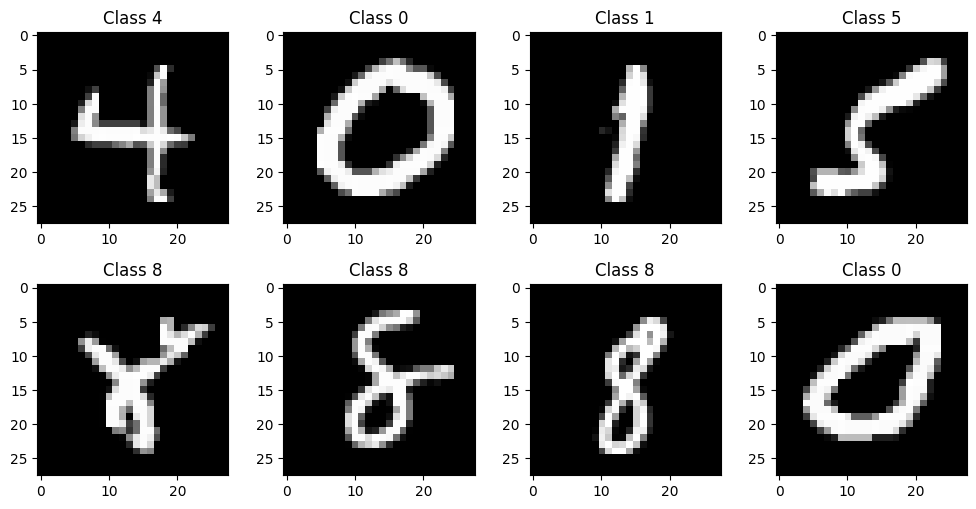

In [32]:
import os

os.environ["OMP_NUM_THREADS"]        = "2"
os.environ["MKL_NUM_THREADS"]        = "2"
os.environ["OPENBLAS_NUM_THREADS"]   = "2"
os.environ["NUMEXPR_NUM_THREADS"]    = "2"

from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y  = mnist.data, mnist.target.astype(int)

#print(X.shape)  
#print(y.shape)

plt.figure(figsize = (10, 10)) # set size of figure 10x10
rand_indexes = np.random.randint(0, X.shape[0], 8) # select 8 digits(0~9) randomly 
print(rand_indexes)

for index,im_index in enumerate(rand_indexes):
    plt.subplot(4, 4, index+1)
    plt.imshow(X[im_index].reshape(28,28), cmap = 'gray', interpolation = 'none')
    plt.title('Class %d' % y[im_index])
plt.tight_layout()

In [3]:
x_train,x_test = X[:60000],X[60000:]
y_train,y_test = y[:60000],y[60000:]

print(x_test.shape)

(10000, 784)


In [35]:
def init_parameters(layers_dim:list)->dict:
    np.random.seed(67)
    param = {}
    L = len(layers_dim)
    for l in range(1,L):
        param[f"w{l}"] = np.random.randn(layers_dim[l],layers_dim[l-1])*np.sqrt(2/layers_dim[l-1])
        param[f"b{l}"] = np.zeros(shape=(layers_dim[l],1))
        
    return param

def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z>0).astype(float)

def soft_max(z):
    expz = np.exp(z - np.max(z,axis=1,keepdims=True))
    return expz/np.sum(expz,axis=1,keepdims=True)



In [36]:
def forward_prop(x,parameter:dict):
 
    chace = {"A0":x}
    A=x
    layer_num = sorted(set(int(k[1:]) for k in parameter.keys()))
    L = len(layer_num)

    for l in range(1,L):
        w = parameter[f"w{l}"]
        b = parameter[f"b{l}"]
        z= np.dot(w,A) + b
        A = relu(z)
        chace[f"z{l}"] = z
        chace[f"A{l}"] = A
    
    w = parameter[f"w{L}"]
    b = parameter[f"b{L}"]

    z= np.dot(w,A) + b
    A = soft_max(z)

    chace[f"z{L}"] = z
    chace[f"A{L}"] = A

    return A,chace



In [37]:
def cross_entropy(y_pred,y_true):
    m = len(y_true)
    y_pred = np.clip(y_pred,1e-9,1 - 1e-9)
    return -(1/m)*np.sum(y_true*np.log(y_pred))

def backward_prop(parameter,chace,y_true):
    grad = {}
    m = len(y_train)
    L = len(sorted(set(int(k[1:]) for k in parameter.keys())))

    dz = chace[f"A{L}"] - y_true

    A_prev = chace[f"A{L-1}"]

    grad[f"dw{L}"] = (1/m)*np.dot(dz,A_prev.T)
    grad[f"db{L}"] = np.sum(dz,axis=1,keepdims=True)/m

    for l in range(L-1,0,-1):
        dA = np.dot(parameter[f"w{l+1}"].T,dz)

        dz = dA * relu_derivative(chace[f"z{l}"])

        A_prev = chace[f"A{l-1}"] if l > 1 else chace["A0"]

        grad[f"dw{l}"] = (1/m)*np.dot(dz,A_prev.T)
        grad[f"db{l}"] = np.sum(dz,axis=1,keepdims=True)/m

    return grad


def update_param(parameter,grad,learning_rate = 0.1):
    L = len(sorted(set(int(k[1:]) for k in parameter.keys())))

    for l in range(1, L + 1):
        parameter[f'w{l}'] -= learning_rate * grad[f'dw{l}']
        parameter[f'b{l}'] -= learning_rate * grad[f'db{l}']
    
    return parameter

def train_step(X, Y, parameters, learning_rate):

    A_L, cache = forward_prop(X, parameters)
    
    cost = cross_entropy(A_L, Y)
    
    grads = backward_prop(parameters, cache, Y)
    
    parameters = update_param(parameters, grads, learning_rate)
    
    return parameters, cost



In [ ]:
import time

def train(X, Y, layer_dims, learning_rate=0.01,
          epochs=1000, batch_size=64, print_every=100):
   
    parameters   = init_parameters(layer_dims)
    cost_history = []

    m = X.shape[1] 

    for epoch in range(epochs):

        permutation = np.random.permutation(m)
        X_shuffled  = X[:, permutation]
        Y_shuffled  = Y[:, permutation]

        epoch_cost = 0
        n_batches  = 0

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[:, i : i + batch_size]
            Y_batch = Y_shuffled[:, i : i + batch_size]

           
            parameters, cost = train_step(
                X_batch, Y_batch, parameters, learning_rate
            )
            epoch_cost += cost
            n_batches  += 1

        
        epoch_cost /= n_batches
        cost_history.append(epoch_cost)

        if epoch % print_every == 0:
            A_L, _    = forward_prop(X, parameters)
            preds     = np.argmax(A_L, axis=0)
            labels    = np.argmax(Y,   axis=0)
            accuracy  = np.mean(preds == labels)
            print(f"Epoch {epoch:>4}  Cost: {epoch_cost:.4f}  "
                  f"Train Acc: {accuracy*100:.2f}%")
        
        time.sleep(0.05)

    return parameters, cost_history

def one_hot(Y, num_classes=10):
    m = Y.shape[0]
    Y_one_hot = np.zeros((num_classes, m))
    Y_one_hot[Y, np.arange(m)] = 1
    return Y_one_hot

Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

X_train = x_train.reshape(x_train.shape[0], -1).T / 255.0  
X_test = x_test.reshape(x_test.shape[0], -1).T / 255.0

layer = [784,64,10]

parameter , cost_hist = train(X_train[:,:5000],Y_train[:,:5000],layer_dims=layer,batch_size=128,epochs=300)




Epoch    0  Cost: 61.6781  Train Acc: 8.98%
Epoch  100  Cost: 60.6037  Train Acc: 12.90%
Epoch  200  Cost: 59.6383  Train Acc: 18.30%
{'w1': array([[ 0.05699898,  0.00728281, -0.05632907, ...,  0.03429449,
        -0.03199807,  0.1289116 ],
       [-0.04520773,  0.05524518,  0.04204518, ...,  0.04901913,
         0.04583751, -0.04777323],
       [-0.02941269,  0.0618405 ,  0.01315505, ...,  0.03569771,
        -0.03104037, -0.03108789],
       ...,
       [-0.07302683,  0.00184428, -0.00524106, ..., -0.101267  ,
        -0.01983234, -0.00609127],
       [-0.00330453,  0.01977593,  0.07904282, ..., -0.04749404,
         0.04179902, -0.00255771],
       [ 0.00214772, -0.0771448 , -0.00089337, ..., -0.00448465,
        -0.00540703, -0.04945527]], shape=(64, 784)), 'b1': array([[ 8.12337174e-03],
       [ 1.07296298e-04],
       [ 3.54896824e-03],
       [-4.15784264e-03],
       [-2.68606264e-03],
       [-5.28663731e-03],
       [ 1.06047418e-02],
       [ 2.63529987e-02],
       [ 1.340